## Synthetic Inversion Example

This notebook demonstrates a complete 1-D TEM inversion workflow on a synthetic dataset:

1. Define a three-layer synthetic earth model.
2. Compute the forward TEM response.
3. Add realistic power-law noise: $e_i = b\,t_i^{-1/2}$ (absolute noise floor in physical units).
4. Run the regularised Gauss-Newton inversion.
5. Inspect the recovered model, data fit, and convergence.

The inversion theory and Jacobian details are covered in [Notebook 2](../2.%20pytem_getJ.ipynb).


In [5]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

# Forward functions, Jacobians, the roughness operator and the inversion driver
# are all part of the pyTEM library (see pytem_fwd.ipynb and pytem_getJ.ipynb for
# the derivations). We import them here rather than re-deriving them.
from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
    getJ_ana,
    getJ_fd,
    getR,
    invert,
)

# Plotting utilities.
from pytem.plotter import plot_model, plot_sounding, plot_inversion


## 1. Synthetic Data

We start from a known **three-layer** earth: a moderately resistive top layer, a **conductive** middle layer, and a resistive basement. The forward TEM response of this "true" model (computed with `fwd_circle_central`) is the clean signal that we will contaminate with noise and then attempt to recover by inversion.


In [6]:
# ---------------------------------------------------------------------------
# Steps 1-2: define a three-layer synthetic earth and compute its TEM response
# ---------------------------------------------------------------------------
# True model (the "ground truth" we will try to recover):
thicknesses0 = [20.0, 30.0]                     # layer thicknesses [m] -> 3 layers
rho0         = np.array([100.0, 20.0, 300.0])   # resistivities [Ohm.m]
depths0      = np.cumsum([0.0] + thicknesses0)  # layer-top depths [m]

# Central-loop acquisition geometry
a     = float(np.sqrt(40.0 ** 2 / np.pi))   # equal-area radius of a 40 x 40 m loop [m]
times = np.logspace(-5, -2, 30)             # gate centre times [s]

# Forward response of the true model (positive dB/dt convention)
dbdt_true = -fwd_circle_central(
    thicknesses=thicknesses0,
    resistivities=rho0.tolist(),
    tx_radius=a,
    times=times,
)

print(f'True model : rho = {rho0} Ohm.m, thicknesses = {thicknesses0} m')
print(f'Geometry   : circular Tx loop, radius a = {a:.2f} m')
print(f'Data       : {len(times)} gates from {times[0] * 1e3:.3f} to {times[-1] * 1e3:.1f} ms')


True model : rho = [100.  20. 300.] Ohm.m, thicknesses = [20.0, 30.0] m
Geometry   : circular Tx loop, radius a = 22.57 m
Data       : 30 gates from 0.010 to 10.0 ms


### Noise Model

Real TEM data contain additive noise whose amplitude grows at early times (high-frequency electromagnetic interference) and decays at late times (signal falls below instrument floor).  A commonly used empirical model is the power-law floor:

$$e_i = b\,t_i^{-1/2}$$

where $b$ is a constant in physical units (e.g. V m$^{-2}$ s$^{1/2}$).  The exponent $-1/2$ is motivated by the $t^{-5/2}$ late-time decay of the TEM signal: a fixed signal-to-noise ratio at late times corresponds to noise decaying as $t^{-5/2+2} = t^{-1/2}$ relative to the signal.  The noise is applied as a Gaussian random perturbation with standard deviation $e_i$:

$$d_i^{obs} = d_i^{true}\left(1 + \frac{e_i}{|d_i^{true}|}\,\varepsilon_i\right), \quad \varepsilon_i \sim \mathcal{N}(0,1)$$


In [7]:
rng = np.random.default_rng(42)

# Power-law noise floor:  e_i = b * t_i^{-1/2}
# b has units of  V/m^2 * sqrt(s)  (sets the absolute late-time noise level)
b_noise   = 1e-11                       # noise amplitude coefficient
noise_std = b_noise * times ** (-0.5)   # absolute std per gate [V/m^2]

# Noisy observed data (additive Gaussian, std = noise_std)
dbdt_obs = dbdt_true + rng.normal(0.0, noise_std)

print(f'SNR range: {(np.abs(dbdt_true) / noise_std).min():.1f} - '
      f'{(np.abs(dbdt_true) / noise_std).max():.1f}')


SNR range: 0.0 - 28101.0


## 2. Inversion Setup

The inversion uses a 1-D log-spaced layered mesh with a homogeneous starting model.


In [ ]:
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667, 
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106, 
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349, 
                   90.604, 99.587, 109.361, 120.001])

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones(len(thicknesses) + 1) * 4.5

In [9]:
# The central-loop circle geometry is the fastest
# option (no side integration required) and the 101-pt DLF is accurate to
# < 0.1 % relative to the 201-pt reference.  We bind these choices here so
# the rest of the notebook uses a single, easy-to-swap definition.


FWD_HANKEL   = 'key_101'            # Hankel filter
FWD_FOURIER  = 'key_81'            # Fourier filter
FWD_NUMBA    = HAS_NUMBA            # use Numba JIT if available
FWD_CUDA     = HAS_CUDA             # use CUDA if available

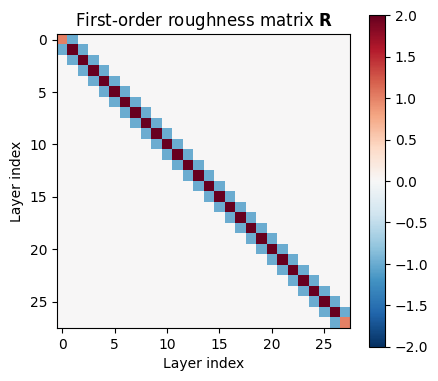

R shape: (28, 28),  diagonal range: 1.000 – 2.000


In [10]:
# ============================================================================
# Roughness matrix visualisation
# ============================================================================
R_vis = getR(np.array(thicknesses))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(R_vis, cmap='RdBu_r', vmin=-R_vis.max(), vmax=R_vis.max())
plt.colorbar(im, ax=ax)
ax.set_title('First-order roughness matrix $\\mathbf{R}$')
ax.set_xlabel('Layer index')
ax.set_ylabel('Layer index')
fig.tight_layout()
plt.show()

print(f"R shape: {R_vis.shape},  diagonal range: {R_vis.diagonal().min():.3f} – {R_vis.diagonal().max():.3f}")

### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

In [ ]:
log_resistivities = np.ones(len(thicknesses) + 1) * np.log(100.0)

result = invert(
    obs_data=dbdt_obs,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_size=a,
    times=times,
    alpha_steps=10,
    maxit=20,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=HAS_CUDA,
    calc_sens=False,
    transform='euler',
    hankel_filter='key_101',
    fourier_filter='key_81',
    max_noise_frac=0.00,
    plot_alpha=True,
    analytical_j=False,
)

# Unpack result dict
best_rho      = result['resistivities']
iter_rms_list = result['rms_history']
rho_hist      = [np.exp(m) for m in result['model_history']]

# Compute modelled response at final model for plotting
mod_data = -fwd_circle_central(
    thicknesses=thicknesses,
    resistivities=best_rho,
    tx_radius=a,
    times=times,
)


Observed data: Mean Apparent Resistivity = 57.8 Ohm.m (over 28/30 valid gates)
Alpha start = 79825189.831
Iteration   1:  RMS = 3997.44
    Alpha = 79825189.83,  RMS = 945.25
    Alpha = 61805745.45,  RMS = 928.09
    Alpha = 47853944.08,  RMS = 911.73
    Alpha = 37051570.98,  RMS = 895.80
    Alpha = 28687685.79,  RMS = 880.42
    Alpha = 22211833.25,  RMS = 866.06
    Alpha = 17197815.81,  RMS = 853.39
    Alpha = 13315644.20,  RMS = 843.16
    Alpha = 10309819.72,  RMS = 836.02
    Alpha = 7982518.98,  RMS = 832.42
Iteration   2:  RMS = 832.42
    Alpha = 10309819.72,  RMS = 123.81
    Alpha = 7982518.98,  RMS = 117.72
    Alpha = 6180574.54,  RMS = 114.50
    Alpha = 4785394.41,  RMS = 112.84
    Alpha = 3705157.10,  RMS = 111.89
    Alpha = 2868768.58,  RMS = 111.15
    Alpha = 2221183.32,  RMS = 110.34
    Alpha = 1719781.58,  RMS = 109.34
    Alpha = 1331564.42,  RMS = 108.12
    Alpha = 1030981.97,  RMS = 106.68
Iteration   3:  RMS = 106.68
    Alpha = 1331564.42,  RMS = 41.15

## 6. Results

Summary plots: data fit, RMS convergence history, and recovered resistivity model vs true model.


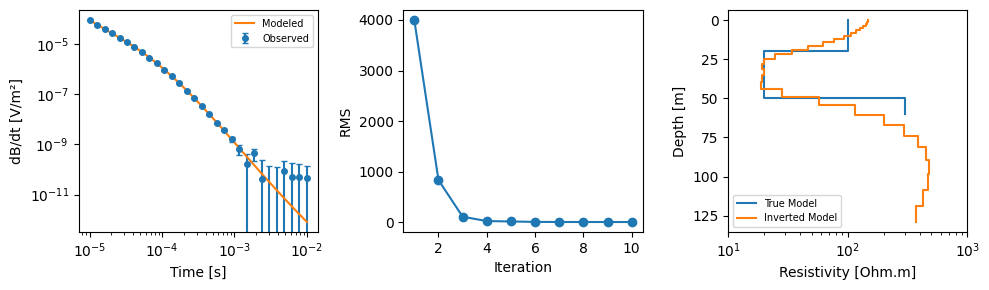

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].errorbar(times, dbdt_obs, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0)))
axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0, depths0[-1]+10], where='pre', label='True Model')
inv_depths = np.concatenate(([0], np.cumsum(thicknesses)))
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[inv_depths, inv_depths[-1]+10], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()